In [57]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [58]:
dataset = 'model/point_history_classifier/point_history.csv'
model_save_path = 'model/point_history_classifier/point_history_classifier.hdf5'

In [59]:
with open('model/point_history_classifier/point_history_classifier_label.csv', encoding='utf-8-sig') as f:
    point_history_labels = [row[0] for row in csv.reader(f)]

print('point history labels:')
for index, label in enumerate(point_history_labels):
    print(f'{index}: {label}')

point history labels:
0: NONE
1: SALUT
2: MULTUMESC
3: TE_ROG
4: AJUTOR
5: STOP
6: BINE
7: NUME
8: PRIETEN
9: LA_REVEDERE
10: BUNA_DIMINEATA
11: BUNA_ZIUA
12: BUNA_SEARA
13: NOAPTE_BUNA
14: BUN_VENIT
15: PE_CURAND
16: CU_PLACERE
17: SCUZE
18: IMI_PARE_RAU
19: FELICITARI
20: LA_MULTI_ANI
21: POATE
22: NU_STIU
23: STIU
24: INTELEG
25: NU_INTELEG
26: REPETA
27: INCET
28: CE
29: CINE
30: UNDE
31: CAND
32: CUM
33: DE_CE
34: CAT_COSTA
35: CUM_TE_NUMESTI
36: CE_MAI_FACI
37: VREAU
38: AM_NEVOIE
39: POT
40: NU_POT
41: AJUTA_MA
42: ASTEAPTA
43: VINO
44: PLEACA
45: GATA
46: INCA
47: MAMA
48: TATA
49: FRATE
50: SORA
51: COPIL
52: BUNIC
53: BUNICA
54: SOT
55: SOTIE
56: FAMILIE
57: FERICIT
58: TRIST
59: SUPARAT
60: OBOSIT
61: SPERIAT
62: IUBESC
63: IMI_PLACE
64: NU_IMI_PLACE
65: FOAME
66: SETE
67: DOARE
68: BOLNAV
69: SANATOS
70: MEDIC
71: SPITAL
72: MEDICAMENT
73: AMETEALA
74: ODIHNA
75: ACUM
76: MAI_TARZIU
77: AZI
78: MAINE
79: IERI
80: DEVREME
81: TARZIU
82: ACASA
83: SCOALA
84: MUNCA
85: MAGAZIN

# 分類数設定

In [60]:
NUM_CLASSES = len(point_history_labels)
print(f'Detected {NUM_CLASSES} classes: {point_history_labels}')

Detected 101 classes: ['NONE', 'SALUT', 'MULTUMESC', 'TE_ROG', 'AJUTOR', 'STOP', 'BINE', 'NUME', 'PRIETEN', 'LA_REVEDERE', 'BUNA_DIMINEATA', 'BUNA_ZIUA', 'BUNA_SEARA', 'NOAPTE_BUNA', 'BUN_VENIT', 'PE_CURAND', 'CU_PLACERE', 'SCUZE', 'IMI_PARE_RAU', 'FELICITARI', 'LA_MULTI_ANI', 'POATE', 'NU_STIU', 'STIU', 'INTELEG', 'NU_INTELEG', 'REPETA', 'INCET', 'CE', 'CINE', 'UNDE', 'CAND', 'CUM', 'DE_CE', 'CAT_COSTA', 'CUM_TE_NUMESTI', 'CE_MAI_FACI', 'VREAU', 'AM_NEVOIE', 'POT', 'NU_POT', 'AJUTA_MA', 'ASTEAPTA', 'VINO', 'PLEACA', 'GATA', 'INCA', 'MAMA', 'TATA', 'FRATE', 'SORA', 'COPIL', 'BUNIC', 'BUNICA', 'SOT', 'SOTIE', 'FAMILIE', 'FERICIT', 'TRIST', 'SUPARAT', 'OBOSIT', 'SPERIAT', 'IUBESC', 'IMI_PLACE', 'NU_IMI_PLACE', 'FOAME', 'SETE', 'DOARE', 'BOLNAV', 'SANATOS', 'MEDIC', 'SPITAL', 'MEDICAMENT', 'AMETEALA', 'ODIHNA', 'ACUM', 'MAI_TARZIU', 'AZI', 'MAINE', 'IERI', 'DEVREME', 'TARZIU', 'ACASA', 'SCOALA', 'MUNCA', 'MAGAZIN', 'TOALETA', 'STRADA', 'MERGEM', 'VORBESTE', 'ASCULTA', 'VEZI', 'UITA_TE', '

# 入力長

In [61]:
TIME_STEPS = 45
DIMENSION = 3  # x, y (body-relative to face anchor) + hand-openness per frame
HANDS = 2  # right + left hand histories concatenated, for two-handed signs

# 学習データ読み込み

In [62]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (TIME_STEPS * DIMENSION * HANDS) + 1)))

In [63]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED, stratify=y_dataset)

# モデル構築

In [65]:
use_lstm = False
model = None

if use_lstm:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION * HANDS, )),
        tf.keras.layers.Reshape((TIME_STEPS * HANDS, DIMENSION), input_shape=(TIME_STEPS * DIMENSION * HANDS, )), 
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(16, input_shape=[TIME_STEPS * HANDS, DIMENSION]),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
else:
    model = tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(TIME_STEPS * DIMENSION * HANDS, )),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(48, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(24, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

In [66]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_4 (Dropout)         (None, 270)               0         
                                                                 
 dense_6 (Dense)             (None, 48)                13008     
                                                                 
 dropout_5 (Dropout)         (None, 48)                0         
                                                                 
 dense_7 (Dense)             (None, 24)                1176      
                                                                 
 dense_8 (Dense)             (None, 101)               2525      
                                                                 
Total params: 16709 (65.27 KB)
Trainable params: 16709 (65.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [67]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [68]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [69]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
1/1 [==============================] - ETA: 0s - loss: 4.3141 - accuracy: 0.1408
Epoch 1: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 1s 708ms/step - loss: 4.3141 - accuracy: 0.1408 - val_loss: 4.1473 - val_accuracy: 0.2500
Epoch 2/1000
1/1 [==============================] - ETA: 0s - loss: 4.2791 - accuracy: 0.1408
Epoch 2: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 0s 62ms/step - loss: 4.2791 - accuracy: 0.1408 - val_loss: 3.9707 - val_accuracy: 0.2500
Epoch 3/1000
1/1 [==============================] - ETA: 0s - loss: 4.0367 - accuracy: 0.1690
Epoch 3: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 0s 60ms/step - loss: 4.0367 - accuracy: 0.1690 - val_loss: 3.8038 - val_accuracy: 0.2500
Epoch 4/1000
1/1 [==============================] - ETA: 0s - loss: 4.0023 

e:\licenta\DeafEar\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 56ms/step - loss: 4.0023 - accuracy: 0.1831 - val_loss: 3.6494 - val_accuracy: 0.2500
Epoch 5/1000
1/1 [==============================] - ETA: 0s - loss: 3.8586 - accuracy: 0.2394
Epoch 5: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 0s 50ms/step - loss: 3.8586 - accuracy: 0.2394 - val_loss: 3.4965 - val_accuracy: 0.2500
Epoch 6/1000
1/1 [==============================] - ETA: 0s - loss: 3.8370 - accuracy: 0.1831
Epoch 6: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 0s 58ms/step - loss: 3.8370 - accuracy: 0.1831 - val_loss: 3.3437 - val_accuracy: 0.2500
Epoch 7/1000
1/1 [==============================] - ETA: 0s - loss: 3.6249 - accuracy: 0.2676
Epoch 7: saving model to model/point_history_classifier\point_history_classifier.hdf5
1/1 [==============================] - 0s 52ms/step - loss: 3.6249 - accurac

In [70]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [71]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 86ms/step
[4.70532868e-05 1.22237248e-10 1.64693593e-05 7.56836585e-07
 9.99935746e-01 3.31342514e-17 1.18662909e-11 1.84882855e-15
 2.11954326e-11 3.61275392e-15 2.35501646e-10 5.69086201e-15
 2.10312457e-15 9.94275967e-16 3.56251588e-14 7.79106927e-17
 2.14318011e-13 5.86773298e-20 1.62666896e-12 3.06045709e-17
 1.74376569e-10 2.83360553e-12 6.87751366e-16 3.68217176e-13
 7.91840890e-14 6.93050963e-14 3.40419803e-10 3.67050039e-15
 1.14956326e-15 1.47160984e-15 6.57491672e-10 1.09233795e-08
 6.85040046e-12 2.24068281e-11 5.16142018e-10 5.59512825e-18
 2.17533379e-19 6.96122504e-20 6.26624982e-17 7.49034412e-16
 7.70975991e-11 3.50380059e-18 2.08679103e-14 8.10996883e-16
 7.65500441e-10 2.13649556e-16 1.58312071e-13 4.12298131e-16
 6.11336543e-14 5.69584727e-11 4.80238904e-11 6.69762345e-16
 2.24148190e-15 1.23018003e-17 4.24205213e-13 4.19935327e-13
 1.34209805e-11 8.16529529e-14 2.41887483e-13 1.97256874e-16
 2.12959372e-10 1.95213515e-14 1.

# 混同行列

1/1 [==============================] - 0s 21ms/step


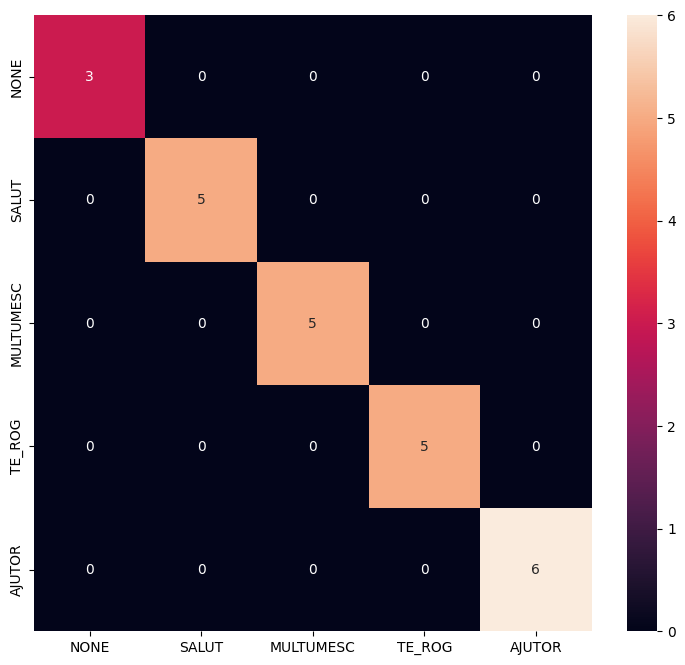

Classification Report
              precision    recall  f1-score   support

        NONE       1.00      1.00      1.00         3
       SALUT       1.00      1.00      1.00         5
   MULTUMESC       1.00      1.00      1.00         5
      TE_ROG       1.00      1.00      1.00         5
      AJUTOR       1.00      1.00      1.00         6

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    label_ids = sorted(list(set(y_true)))
    label_names = [point_history_labels[i] for i in label_ids]
    cmx_data = confusion_matrix(y_true, y_pred, labels=label_ids)
    
    df_cmx = pd.DataFrame(cmx_data, index=label_names, columns=label_names)
 
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(label_ids), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred, labels=label_ids, target_names=label_names))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [73]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)
model = tf.keras.models.load_model(model_save_path)

e:\licenta\DeafEar\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [74]:
tflite_save_path = 'model/point_history_classifier/point_history_classifier.tflite'

In [75]:
# モデルを変換(量子化
converter = tf.lite.TFLiteConverter.from_keras_model(model)  # converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmpn5ygudez\assets


INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmpn5ygudez\assets


19520

# 推論テスト

In [76]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [77]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(input_details)

[{'name': 'serving_default_input_3:0', 'index': 0, 'shape': array([  1, 270]), 'shape_signature': array([ -1, 270]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [78]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [79]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [80]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[4.5344856e-05 1.2531388e-10 1.6705779e-05 7.9813969e-07 9.9993718e-01
 3.5330528e-17 1.2009389e-11 2.0193352e-15 2.1336086e-11 3.6849694e-15
 2.2229997e-10 5.7982878e-15 2.2036045e-15 1.0532151e-15 3.7165661e-14
 8.1267306e-17 2.1558803e-13 6.4138932e-20 1.6480007e-12 3.0985809e-17
 1.7443733e-10 2.8760867e-12 6.9979374e-16 3.8990767e-13 7.9733576e-14
 6.7078145e-14 3.5377182e-10 3.7830054e-15 1.2330678e-15 1.7290618e-15
 6.8773742e-10 1.1136629e-08 7.2642374e-12 2.4314249e-11 5.1323690e-10
 6.0705900e-18 2.3436984e-19 7.9924892e-20 6.1754419e-17 7.5030517e-16
 8.0297623e-11 3.7238240e-18 2.0797449e-14 8.3214216e-16 7.6249385e-10
 2.3483022e-16 1.6269156e-13 4.2123965e-16 6.3694398e-14 5.8711036e-11
 4.5385164e-11 6.9948944e-16 2.3465665e-15 1.3497099e-17 4.1365178e-13
 4.2870709e-13 1.3751801e-11 8.0583943e-14 2.4332134e-13 2.0396956e-16
 2.2360847e-10 1.9568497e-14 1.4862125e-11 1.6750780e-15 3.1273456e-11
 1.0356810e-11 8.6130545e-14 1.0883535e-14 2.0266630e-11 2.1019633e-16
 3.882